In [1]:
from autstr.buildin.presentations import BuechiArithmetic

# Load Büchi Arithmetic
Since many predifined relations of the structure are dynamically generated upon creation, this might take a few seconds.

In [2]:
%%time
ba = BuechiArithmetic()

CPU times: user 21.2 ms, sys: 1.08 ms, total: 22.3 ms
Wall time: 34.5 ms


# Visualize Addition 
We can explore the presentations visually with the ```show_diagram``` method.

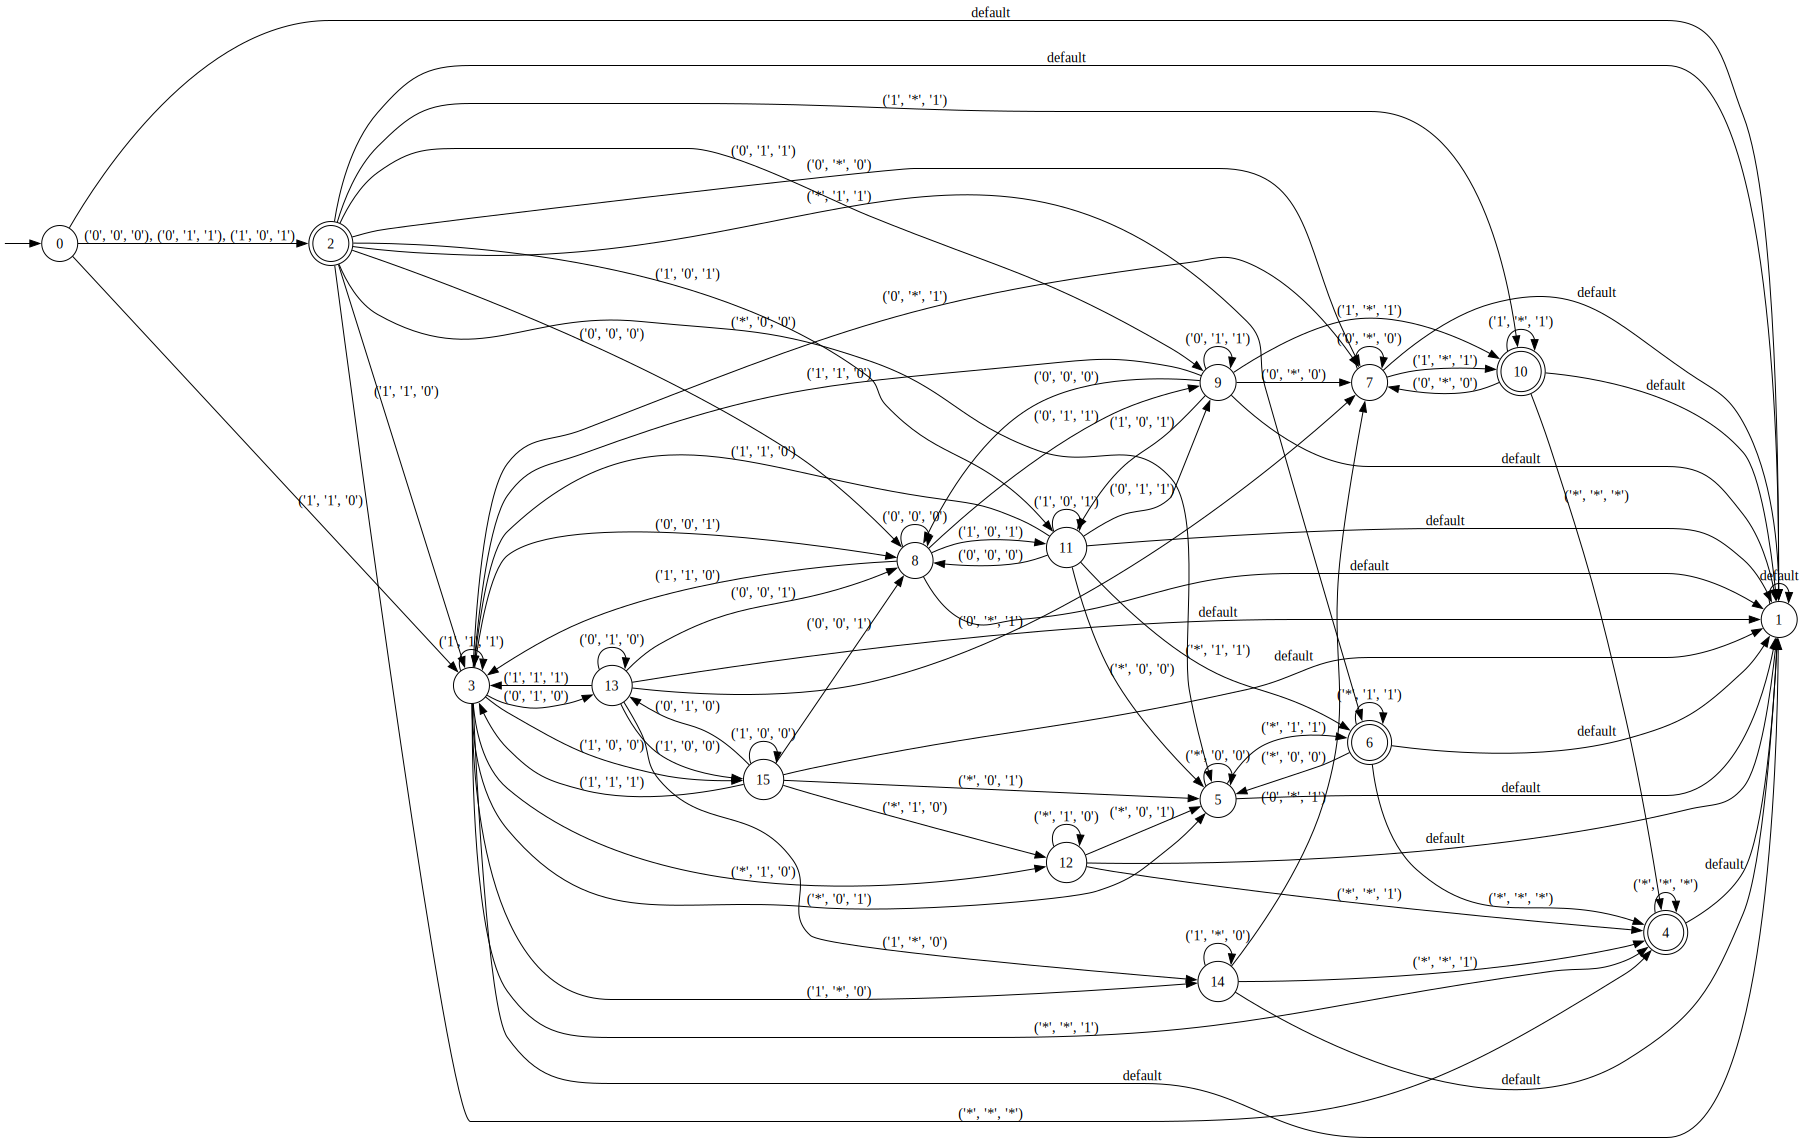

In [3]:
ba.automata["A"].show_diagram()

# Define Zero
We will make use of the fact that $0$ is the only number that satisfies $x+x=x$ 

In [4]:
%%time
ba.update(O='A(x,x,x)')

CPU times: user 2.46 ms, sys: 29 μs, total: 2.49 ms
Wall time: 2.22 ms


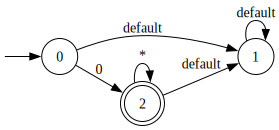

In [5]:
ba.automata['O'].show_diagram()

# Define One
$1$ is the only number apart from $0$ that has only trivial additive decompositions.

In [6]:
%%time
# Define one
ba.update(I='not O(x) and forall y z.(O(y) or O(z) or not A(y, z, x))')

CPU times: user 39.5 ms, sys: 1.1 ms, total: 40.6 ms
Wall time: 39.2 ms


You can also convert the automaton to a string to obtain a readable representation

In [7]:
print(ba.automata['I'])

SparseDFA with 3 states (arity=1)
Start state: 0
Accepting states: [2]

Transitions:
State | Default | Exceptions
------|---------|-----------
0     | 1       | ('1',)→2
1     | 1       | None
2*    | 1       | ('*',)→2


# Define Successor

In [8]:
%%time
ba.update(S='exists x.(I(x) and A(u, x, v))')

CPU times: user 9.51 ms, sys: 36 μs, total: 9.55 ms
Wall time: 9.02 ms


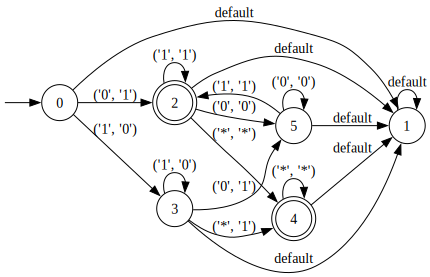

In [9]:
ba.automata['S'].show_diagram()

# Define powers of $2$

CPU times: user 2.07 ms, sys: 1.99 ms, total: 4.07 ms
Wall time: 26.2 ms


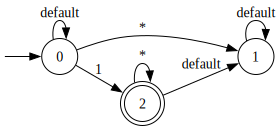

In [10]:
%%time
ba.update(P='B(x,x)')
ba.automata['P'].show_diagram()

CPU times: user 16.4 ms, sys: 1.09 ms, total: 17.5 ms
Wall time: 78 ms


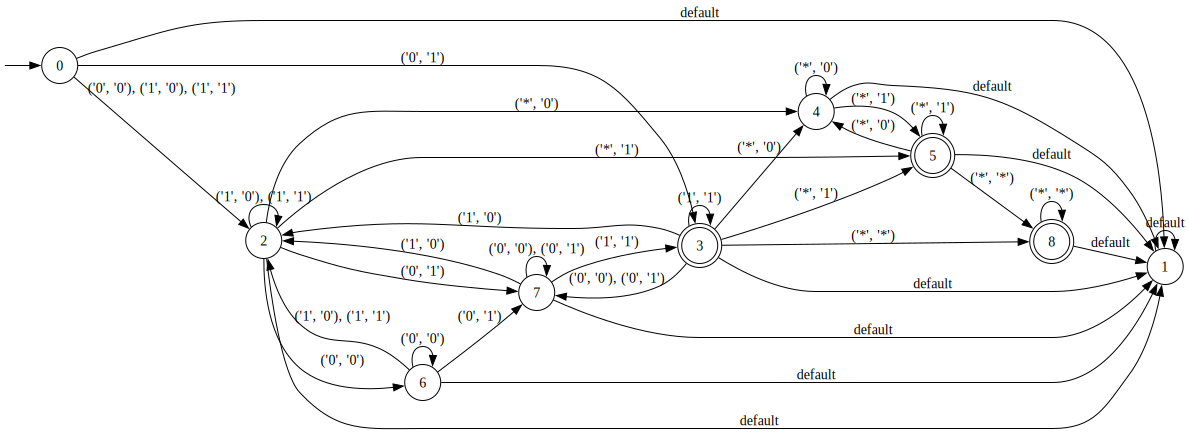

In [11]:
%%time
# Define linear order
ba.update(Smaller='exist z.(not O(z) and A(x, z, y))')
ba.automata['Smaller'].show_diagram()

# Define Bit Predicate
The bit predicate lets us effective "talk" about the binary presentation of a number within formulas. Positions in the presentation are represented as powers of $2$:
$$
 \textrm{BitPredicate(x,y)} \colon\Leftrightarrow y=2^n \land bin(x)[n] = 1
$$

In [12]:
%%time
# Define bit predicate E(x, y) <=> y==2^n bin(x)[n] == 1
ba.update(
    Theorem='exists x0 x1.(P(y) and Smaller(x0, y) and A(x0, x1, x) and B(x1, y) and not exists y1.(Smaller(y, y1) and B(x1, y1)))'
)


CPU times: user 39.1 ms, sys: 2.01 ms, total: 41.1 ms
Wall time: 39.8 ms


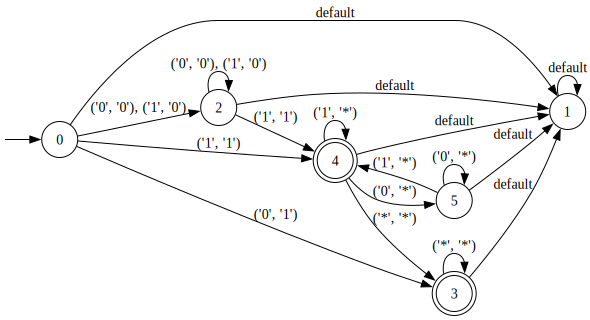

In [13]:
ba.automata['Theorem'].show_diagram()

# Proof the "Sandwich Theorem"
Finally, we will prove a small theorem: For every positive natural number $x$ there is a power of two in $[x, 2x]$.

In [14]:
%%time
# Evaluate 'For all x>0 there is a power of 2 in [x, 2x]'
a = ba.evaluate('forall x.(O(x) or exists y u v w.(A(x, x, y) and A(x, u, v) and P(v) and A(v, w, y)))')

CPU times: user 49.2 ms, sys: 2.88 ms, total: 52.1 ms
Wall time: 54.4 ms


Formulas without free variables (sentences), the result automaton will have exactly one state that is excepting iff the sentence is true. Alternatively, you can also call ```check``` instead of ```evaluate``` to directly obtain the truth value.

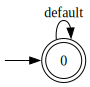

In [15]:
a.show_diagram()